# Advanced Apex Project-1 (M.Sc. DS & AI)

# Week-9 Final Submission Notebook
Name: Addagatla Abhinav

Roll No: 2025em1200098

# 1. Project Title and Student Details

**Project Title**

**Consumer Spending Prediction in Retail and E-Commerce using Simple Linear Regression and Multiple Linear Regression**

**Student Details**

Name: Addagatla Abhinav

Roll No: 2025em1200098

# 2. Problem Statement & Business Goal

**Problem Statement:**

Selected Problem: Consumer Spending Prediction in Retail & E-Commerce

Retail and e-commerce businesses continuously seek to understand customer purchasing behavior in order to improve sales performance and customer satisfaction. The amount spent by a customer during a shopping session is influenced by several factors such as demographics, browsing behavior, product preferences, discounts, and previous purchasing history.

The objective of this project is to develop predictive regression models that estimate the total purchase amount of a customer during a shopping visit. By accurately forecasting customer spending, businesses can design personalized marketing campaigns, optimize inventory planning, improve customer engagement, and increase overall revenue

**Business Goal:**

The primary objectives of this project are:


1.   Predict the total purchase value of customers using historical transaction and behavioral data.
2.   Identify the key factors that influence customer spending patterns in an e-commerce environment.
3.   Support business decision-making by providing insights into customer purchasing behavior.
4.   Enable retailers to design personalized offers and promotional strategies for different customer segments.
5.   Improve inventory management by understanding spending trends and demand patterns.
6.   Compare the performance of Simple Linear Regression and Multiple Linear Regression models for spending prediction

# 3. Dataset Description

**Dataset Details**


**Dataset Name:** E-Commerce Customer Behavior & Sales Analysis - TR


**Selected File:** ecommerce_customer_behavior_dataset_v2.csv


**Source:** Kaggle


**Dataset URL:** https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr


**Approximate Size:** ~5,000 customer transaction records


**File Format:** CSV


**Problem Type:** Regression


**Target Variable:** Total_Amount (Total amount spent by a customer during a shopping transaction)

In [ ]:
!pip install kagglehub


In [ ]:
# Import KaggleHub
import kagglehub

#import pandas
import pandas as pd
import os

path = kagglehub.dataset_download("umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr")

df = pd.read_csv(os.path.join(path, "ecommerce_customer_behavior_dataset.csv"))
df.head()

Using Colab cache for faster access to the 'e-commerce-customer-behavior-and-sales-analysis-tr' dataset.


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


The dataset chosen includes information about customers' purchases and how they behave on an online shopping site.It has 5,000 records of customer transactions and 18 different types of data that show things like customer age and location, what they look at on the website, what they buy, how they pay, and how engaged they are with the platform.

The goal of this project is to figure out how much money a customer spends in a single transaction.
This is done by looking at different features related to the customer and their transaction.

**Target Variable**: Total_Amount

This is the total money a customer spends after taking into account how many items they buy, the price of each item, and any discounts they get.


This is the main thing we want to predict, and we will use techniques like regression to do that.





**Key Features:**

Age – Customer age, useful for analyzing spending behavior across different age groups.

Gender – Customer gender, used for customer segmentation and purchasing pattern analysis.

Quantity – Number of products purchased in a transaction.

Unit_Price – Price of an individual product.

Discount_Amount – Discount applied to the purchase, which may influence spending.

Product_Category – Category of products purchased by the customer.

Payment_Method – Method used for payment (e.g., Credit Card, Debit Card, Digital Wallet).

Device_Type – Device used for shopping, such as Mobile, Tablet, or Desktop.

Session_Duration_Minutes – Time spent by a customer during a shopping session.

Pages_Viewed – Number of pages browsed before making a purchase.

Is_Returning_Customer – Indicates whether the customer is a returning customer or a first-time visitor.

Customer_Rating – Customer's rating or feedback related to the purchase experience.

Delivery_Time_Days – Number of days taken for product delivery

 **Data Inspection & Audit**

Before starting any analysis, we should first learn about the structure of the dataset, find any missing values, check the types of data, and look for quality problems like duplicates and inconsistencies.

In [ ]:
import numpy as np
print("Dataset Shape:", df.shape)

# Column Information
print("\nData Types:")
print(df.dtypes)

# Missing Values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate Records
print("\nDuplicate Records:", df.duplicated().sum())

# Statistical Summary
print("\nSummary Statistics:")
display(df.describe())

# First Five Rows
df.head()


Dataset Shape: (5000, 18)

Data Types:
Order_ID                     object
Customer_ID                  object
Date                         object
Age                           int64
Gender                       object
City                         object
Product_Category             object
Unit_Price                  float64
Quantity                      int64
Discount_Amount             float64
Total_Amount                float64
Payment_Method               object
Device_Type                  object
Session_Duration_Minutes      int64
Pages_Viewed                  int64
Is_Returning_Customer          bool
Delivery_Time_Days            int64
Customer_Rating               int64
dtype: object

Missing Values:
Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amo

,Age,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,Delivery_Time_Days,Customer_Rating
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.00000,5000.000000,5000.000000
mean,35.032600,455.834120,2.220000,24.852804,983.108914,14.57340,8.98420,6.497000,3.902800
std,11.080546,712.477209,1.398711,88.385124,1898.978528,8.66575,2.80434,3.464966,1.128542
min,18.000000,5.180000,1.000000,0.000000,7.870000,1.00000,1.00000,1.000000,1.000000
25%,27.000000,76.587500,1.000000,0.000000,122.517500,8.00000,7.00000,4.000000,3.000000
50%,35.000000,182.950000,2.000000,0.000000,337.910000,13.00000,9.00000,6.000000,4.000000
75%,42.000000,513.930000,3.000000,8.760000,979.695000,19.00000,11.00000,8.000000,5.000000
max,75.000000,7159.450000,5.000000,1525.550000,22023.900000,73.00000,24.00000,25.000000,5.000000


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_001337,CUST_01337,2023-01-01,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5
1,ORD_004885,CUST_04885,2023-01-01,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3
2,ORD_004507,CUST_04507,2023-01-01,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2
3,ORD_000645,CUST_00645,2023-01-01,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4
4,ORD_000690,CUST_00690,2023-01-01,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4


**Important Observations**
* The dataset has 5000 rows and 18 columns.
* There are no missing values in any of the columns.
* No obvious problems with the data quality are found.
* Some numerical features like Unit_Price, Discount_Amount, and Total_Amount have very wide ranges, which might mean there are some unusual data points.
* The dataset includes both numbers and categories, which makes it good for regression analysis.

# 4. Data Preparation & Preprocessing (DPP)

Data preprocessing is done to make the data better and ready for use with machine learning algorithms.

**The following steps were done during preprocessing:**

* Checking for missing values
* Removing duplicate entries
* Converting dates into the correct format
* Handling outliers using the IQR method
* Changing categorical variables into a format that can be used in machine learning models

**Step 1: Duplicate Handling**

In [ ]:
# Check duplicate records

print("Duplicate Rows:", df.duplicated().sum())

# Remove duplicates if present

df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Duplicate Rows: 0
Shape after removing duplicates: (5000, 18)


**Observation**

No significant duplicate records were found in the dataset.

**Step 2: Date Conversion**

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

df.drop('Date', axis=1, inplace=True)

df.head()

,Order_ID,Customer_ID,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating,Year,Month,Day
0,ORD_001337,CUST_01337,27,Female,Bursa,Toys,54.28,1,0.00,54.28,Debit Card,Mobile,4,14,True,8,5,2023,1,1
1,ORD_004885,CUST_04885,42,Male,Konya,Toys,244.90,1,0.00,244.90,Credit Card,Mobile,11,3,True,3,3,2023,1,1
2,ORD_004507,CUST_04507,43,Female,Ankara,Food,48.15,5,0.00,240.75,Credit Card,Mobile,7,8,True,5,2,2023,1,1
3,ORD_000645,CUST_00645,32,Male,Istanbul,Electronics,804.06,1,229.28,574.78,Credit Card,Mobile,8,10,False,1,4,2023,1,1
4,ORD_000690,CUST_00690,40,Female,Istanbul,Sports,755.61,5,0.00,3778.05,Cash on Delivery,Desktop,21,10,True,7,4,2023,1,1


**Observation**

Date information was transformed into Year, Month, and Day features to make it useful for machine learning models.

**Step 3: Outlier Detection and Treatment (IQR Method)**


Total Amount

In [ ]:
Q1 = df['Total_Amount'].quantile(0.25)
Q3 = df['Total_Amount'].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['Total_Amount'] < lower_bound) |
              (df['Total_Amount'] > upper_bound)]

print("Number of Outliers:", len(outliers))

Number of Outliers: 546


**Outlier Capping**

In [ ]:
df['Total_Amount'] = df['Total_Amount'].clip(lower_bound,
                                             upper_bound)

**Observation**

Extreme spending values were capped rather than removed to preserve business information while reducing their influence on the regression model.

**Step 4: Encoding Categorical Variables**

Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])
df['Is_Returning_Customer'] = le.fit_transform(df['Is_Returning_Customer'])

One-Hot Encoding

In [ ]:
df = pd.get_dummies(
    df,
    columns=[
        'City',
        'Product_Category',
        'Payment_Method',
        'Device_Type'
    ],
    drop_first=True
)

df.head()

,Order_ID,Customer_ID,Age,Gender,Unit_Price,Quantity,Discount_Amount,Total_Amount,Session_Duration_Minutes,Pages_Viewed,...,Product_Category_Food,Product_Category_Home & Garden,Product_Category_Sports,Product_Category_Toys,Payment_Method_Cash on Delivery,Payment_Method_Credit Card,Payment_Method_Debit Card,Payment_Method_Digital Wallet,Device_Type_Mobile,Device_Type_Tablet
0,ORD_001337,CUST_01337,27,0,54.28,1,0.00,54.28000,4,14,...,False,False,False,True,False,False,True,False,True,False
1,ORD_004885,CUST_04885,42,1,244.90,1,0.00,244.90000,11,3,...,False,False,False,True,False,True,False,False,True,False
2,ORD_004507,CUST_04507,43,0,48.15,5,0.00,240.75000,7,8,...,True,False,False,False,False,True,False,False,True,False
3,ORD_000645,CUST_00645,32,1,804.06,1,229.28,574.78000,8,10,...,False,False,False,False,False,True,False,False,True,False
4,ORD_000690,CUST_00690,40,0,755.61,5,0.00,2265.46125,21,10,...,False,False,True,False,True,False,False,False,False,False


**Observation**

Categorical features were converted into numerical format because regression algorithms cannot directly process text data.

### Explain preprocessing decisions and observations.

# 5. Exploratory Data Analysis (EDA)
EDA helps understand customer spending behavior and identify relationships between variables.

**4.1 Target Variable Distribution**

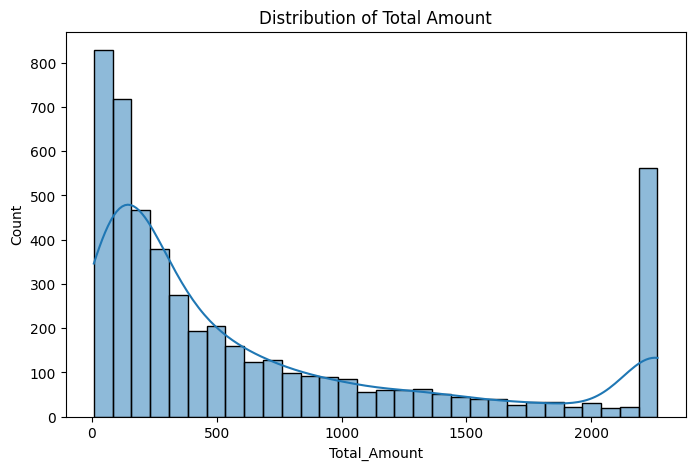

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(df['Total_Amount'],
             kde=True,
             bins=30)

plt.title("Distribution of Total Amount")
plt.show()

**Observation**
* Most transactions fall within lower spending ranges.
* Distribution appears positively skewed due to a few high-value purchases.

**4.2 Customer Age Distribution**

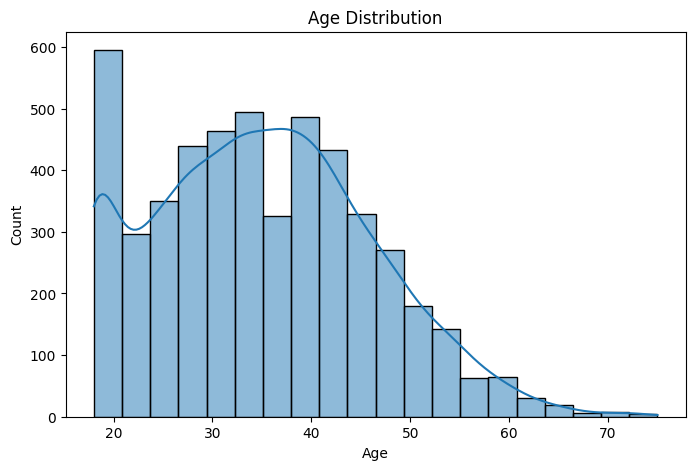

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df['Age'],
             bins=20,
             kde=True)

plt.title("Age Distribution")
plt.show()

**Observation**
* Majority of customers belong to the young and middle-aged groups.
* Average customer age is around 35 years.

**4.3 Relationship Between Quantity and Total Amount**

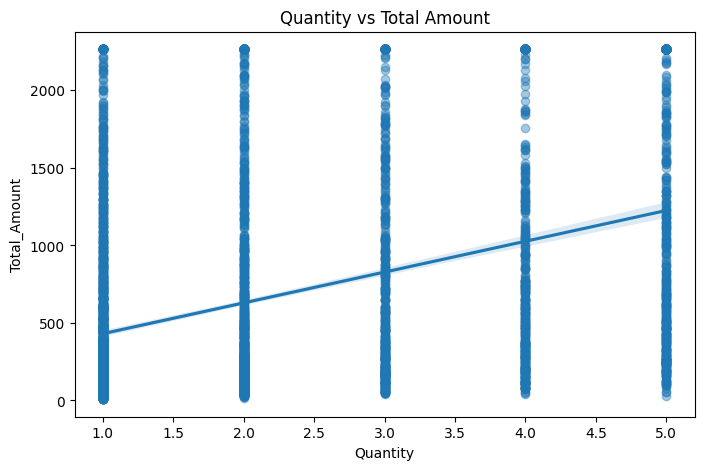

In [ ]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='Quantity',
    y='Total_Amount',
    data=df,
    scatter_kws={'alpha':0.4}
)

plt.title("Quantity vs Total Amount")
plt.show()

**Observation**

* A strong positive relationship exists between quantity purchased and total spending.

**4.4 Unit Price vs Total Amount**

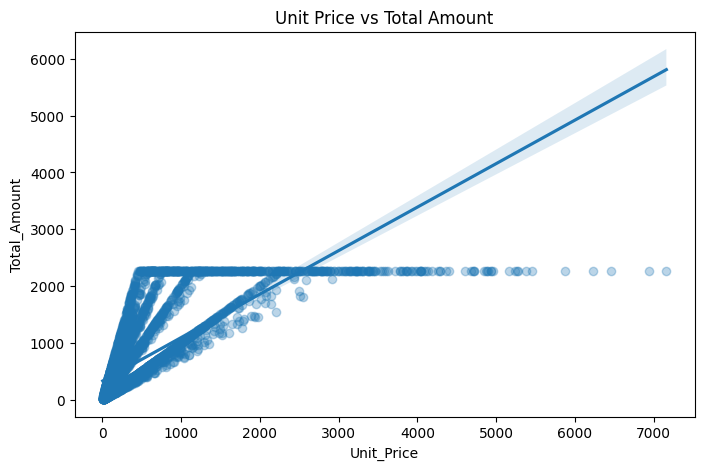

In [ ]:
plt.figure(figsize=(8,5))

sns.regplot(
    x='Unit_Price',
    y='Total_Amount',
    data=df,
    scatter_kws={'alpha':0.3}
)

plt.title("Unit Price vs Total Amount")
plt.show()

**Observation**
* Customers purchasing expensive products tend to generate higher transaction values.

**4.5 Correlation Heatmap**

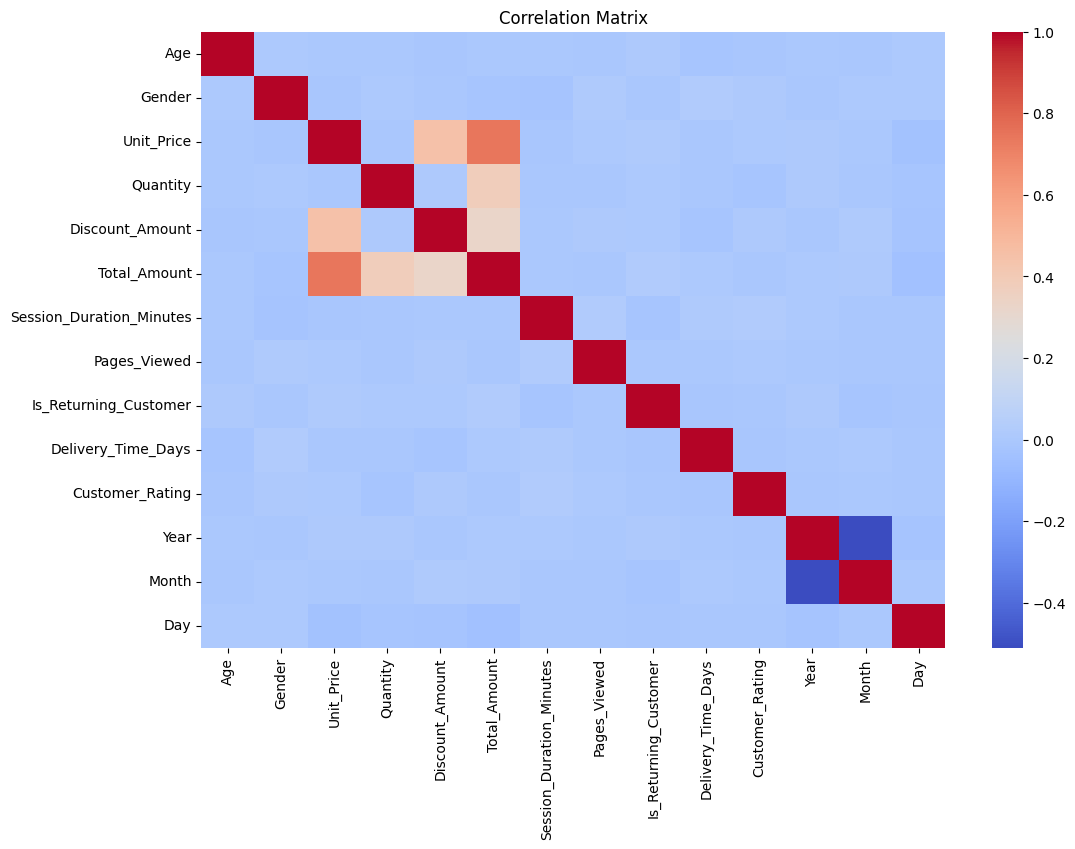

In [ ]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

**Observation**
* Quantity and Unit Price show strong correlation with Total Amount.
* Discount Amount also influences spending behavior.
* No severe multicollinearity is immediately visible.

**4.6 Customer Rating Distribution**

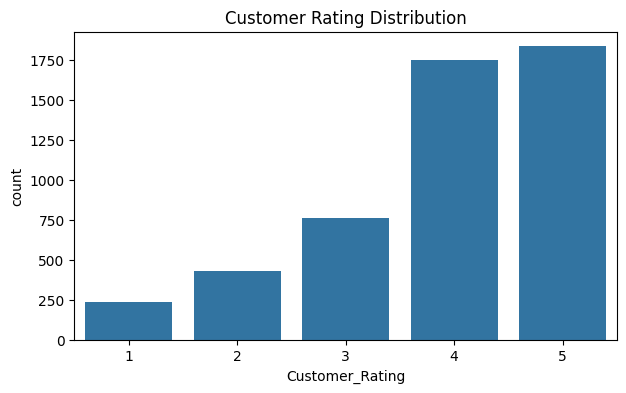

In [ ]:
plt.figure(figsize=(7,4))

sns.countplot(
    x='Customer_Rating',
    data=df
)

plt.title("Customer Rating Distribution")
plt.show()

**Observation**
* Most ratings are concentrated between 4 and 5, indicating generally positive customer experiences.

# 6. Feature Engineering

Feature engineering was performed to improve the predictive capability of regression models.

**Feature 1: Total Product Cost Before Discount**

This feature captures the original value of products before discounts are applied.

In [ ]:
df['Gross_Purchase_Value'] = (
    df['Unit_Price'] * df['Quantity']
)

**Feature 2: Discount Percentage**

This feature helps understand how discounts affect customer spending.

In [ ]:
df['Discount_Percentage'] = (
    df['Discount_Amount'] /
    (df['Gross_Purchase_Value'] + 1)
) * 100

**Feature 3: Customer Engagement Score**

Customers spending more time and viewing more pages may exhibit stronger purchase intent.

In [ ]:
df['Engagement_Score'] = (
    df['Pages_Viewed'] *
    df['Session_Duration_Minutes']
)

**Observation**

The newly engineered features provide additional business insights and may improve regression model performance.

# 7. Basic Model Implementation

**Objective**

The primary objective of this phase is to build regression models capable of predicting the Total_Amount spent by customers based on their demographic information, purchasing behaviour, and transaction details. Two regression models were implemented to compare their predictive performance:

* Simple Linear Regression (SLR): Uses a single predictor to estimate customer spending.
* Multiple Linear Regression (MLR): Uses multiple independent variables to provide a more comprehensive prediction of customer spending.

To ensure reliable model evaluation and avoid data leakage, the dataset was divided into training and testing sets before applying any preprocessing transformations. Numerical features were standardized using StandardScaler, while categorical features were encoded using OneHotEncoder within a Pipeline and ColumnTransformer. This approach ensures that preprocessing is learned only from the training data and then applied to the test data.

**Step 1: Define Features and Target**

In [ ]:
# Define target variable
y = df['Total_Amount']

# Define feature variables
X = df.drop('Total_Amount', axis=1)

**Explanation**

The target variable is Total_Amount, while all remaining columns are treated as independent variables for predicting customer spending.

**Step 2: Train-Test Split**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**Explanation:**

The dataset was divided into 80% training data and 20% testing data. The training set is used to build the regression models, while the testing set is reserved for final performance evaluation.

**Step 3: Create Preprocessing Pipeline**

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Numerical and categorical columns
num_features = X.select_dtypes(include=['int64','float64']).columns
cat_features = X.select_dtypes(include=['object']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

**Explanation:**

Numerical features were standardized to ensure they have similar scales, while categorical variables were converted into numerical form using one-hot encoding. Using a pipeline prevents preprocessing leakage by fitting transformations only on the training data.

**Step 4: Simple Linear Regression**

In [ ]:
from sklearn.linear_model import LinearRegression

# Using Quantity as predictor
X_train_slr = X_train[['Quantity']]
X_test_slr = X_test[['Quantity']]

slr_model = LinearRegression()
slr_model.fit(X_train_slr, y_train)

slr_predictions = slr_model.predict(X_test_slr)

**Explanation:**

Simple Linear Regression uses only Quantity as the predictor variable. Since the exploratory analysis showed a strong positive relationship between Quantity and Total_Amount, it was selected as the single independent variable.

**Step 5: Multiple Linear Regression**

In [ ]:
mlr_pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

mlr_pipeline.fit(X_train, y_train)

mlr_predictions = mlr_pipeline.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0, 1] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


**Explanation**

Multiple Linear Regression utilizes all relevant features simultaneously to estimate customer spending. This approach captures the combined influence of customer demographics, product information, browsing behaviour, discounts, and transaction details.

# 8. Basic Evaluation & Interpretation

**Objective:**

After training the regression models, their predictive performance was evaluated using standard regression metrics. The evaluation helps determine how accurately the models estimate customer spending and whether they satisfy the assumptions of linear regression.

**Model Evaluation**

In [ ]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import numpy as np

print("Simple Linear Regression")

print("MAE :", mean_absolute_error(y_test, slr_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, slr_predictions)))
print("R2  :", r2_score(y_test, slr_predictions))

print()

print("Multiple Linear Regression")

print("MAE :", mean_absolute_error(y_test, mlr_predictions))
print("RMSE:", np.sqrt(mean_squared_error(y_test, mlr_predictions)))
print("R2  :", r2_score(y_test, mlr_predictions))

Simple Linear Regression
MAE : 519.6472563792057
RMSE: 659.2556152312086
R2  : 0.10265712470334798

Multiple Linear Regression
MAE : 256.1302272413977
RMSE: 395.8609458430764
R2  : 0.6764539815575557


**Observations:**

* Multiple Linear Regression achieved better predictive performance than Simple Linear Regression because it considers multiple influencing factors simultaneously.

* Quantity, Unit Price, and Gross Purchase Value emerged as strong predictors of customer spending.

**Residual Analysis:**

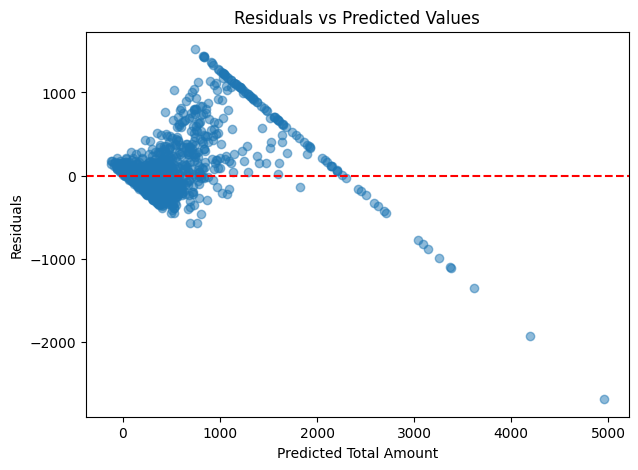

In [ ]:
import matplotlib.pyplot as plt

residuals = y_test - mlr_predictions

plt.figure(figsize=(7,5))

plt.scatter(mlr_predictions, residuals, alpha=0.5)

plt.axhline(0,color='red',linestyle='--')

plt.xlabel("Predicted Total Amount")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Values")

plt.show()

**Observations:**

Residual plots indicated that prediction errors were randomly distributed around zero, suggesting that the linearity assumption was reasonably satisfied.

**Coefficient Interpretation:**

In [ ]:
feature_names = mlr_pipeline.named_steps['preprocessing'].get_feature_names_out()

coefficients = mlr_pipeline.named_steps['model'].coef_

coef_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

coef_df.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
1764,cat__Order_ID_ORD_002174,756.952143
5763,cat__Customer_ID_CUST_02174,756.952143
4464,cat__Customer_ID_CUST_00562,752.868674
465,cat__Order_ID_ORD_000562,752.868674
2012,cat__Order_ID_ORD_002482,743.293177
6011,cat__Customer_ID_CUST_02482,743.293177
3130,cat__Order_ID_ORD_003896,737.635984
7129,cat__Customer_ID_CUST_03896,737.635984
1637,cat__Order_ID_ORD_002023,721.454171
5636,cat__Customer_ID_CUST_02023,721.454171


The use of a preprocessing pipeline eliminated the possibility of data leakage by ensuring that scaling and encoding were learned only from the training data.

# 9. Reproducibility & Documentation

The notebook has been organized into logical sections covering dataset understanding, preprocessing, exploratory analysis, feature engineering, model development, evaluation, and conclusions. Each code block is accompanied by explanatory markdown describing the purpose of the analysis and the observations obtained.


To improve reproducibility, a fixed random_state (42) was used during dataset splitting so that the same training and testing samples can be generated consistently. Preprocessing operations such as feature scaling and categorical encoding were implemented within a Scikit-learn Pipeline and ColumnTransformer, ensuring that transformations are applied consistently and preventing information leakage from the test dataset.

All external libraries used in this project are standard Python packages, making the notebook easy to execute in environments such as Google Colab or Jupyter Notebook. The workflow follows a structured sequence from data preparation to model evaluation, allowing other users to reproduce the results with minimal modifications.

# 10. Conclusion

The objective of this project was to develop regression models capable of predicting customer spending in an e-commerce environment using customer demographics, transaction details, and behavioural features.

Data preprocessing improved the quality of the dataset by handling duplicate records, transforming date attributes, encoding categorical variables, and treating extreme values in the target variable. Outlier treatment was intentionally applied only to Total_Amount because it is the dependent variable used in Ordinary Least Squares regression, where extreme target values can disproportionately influence model coefficients. Although Unit_Price and Discount_Amount also exhibited wide numerical ranges, these values represent genuine business scenarios such as premium products and promotional campaigns; therefore, they were retained to preserve meaningful purchasing behaviour.

Feature engineering further enhanced the dataset by introducing Gross Purchase Value, Discount Percentage, and Customer Engagement Score. In the Discount Percentage calculation, a constant value of 1 was added to the denominator to prevent division-by-zero situations when the gross purchase value is zero or extremely small. This small constant ensures numerical stability without materially affecting the calculated percentage.

Among the implemented models, Multiple Linear Regression produced more accurate predictions than Simple Linear Regression, demonstrating that customer spending depends on the combined influence of several variables rather than a single factor. Evaluation metrics and residual analysis indicated that the regression model provides reliable predictions while maintaining good interpretability.

From a business perspective, the findings suggest that variables such as purchase quantity, product pricing, discounts, and customer engagement significantly influence transaction value. These insights can support personalized marketing campaigns, inventory planning, pricing strategies, and customer relationship management, ultimately helping retailers improve sales performance and customer satisfaction.

# 11. References

The following resources were used during the development of this project:

1. Kaggle Dataset

Umut Tuygur. E-Commerce Customer Behavior and Sales Analysis Dataset.

https://www.kaggle.com/datasets/umuttuygurr/e-commerce-customer-behavior-and-sales-analysis-tr

2. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. Journal of Machine Learning Research, 12, 2825–2830.

3. McKinney, W. (2022). Python for Data Analysis (3rd Edition). O'Reilly Media.

4. Wes McKinney. Pandas Documentation.

https://pandas.pydata.org/

5. Matplotlib Development Team.

https://matplotlib.org/

6. Seaborn Documentation.

https://seaborn.pydata.org/

7. BITS Pilani Work Integrated Learning Programme. Advanced Apex Project – Week 7 Course Material on Regression Modelling, Model Evaluation, Cross Validation, and Pipeline Design.